### Copyright 2026 Jens Liebehenschel, Frankfurt University of Applied Sciences, FB2, Computer Science
### No liability or warranty; only for educational and non-commercial purposes
### See some basic hints for working with Jupyter notebooks in README.md
## Data structure max priority queue - implemented as max-heap - with visualization of the steps

## Constants and global variables

In [1]:
# maximal size of the max priority queue
MAX_NUM_ELEMENTS = 10
# implementation as a heap
heap = [-1]*MAX_NUM_ELEMENTS
heapsize = 0

### Functions

In [2]:
def empty_max_priority_queue():
    global steps, heap, heapsize
    steps=[]
    heap = [-1]*MAX_NUM_ELEMENTS
    heapsize = 0
    # nothing yet in max priority queue
    steps.append([[EMPTY]*MAX_NUM_ELEMENTS, [], [], heap[:]])

In [3]:
# navigating up and down in the heap, valid for heaps with first element at index 0
def left_child(i):
    return 2*i + 1
def right_child(i):
    return 2*i + 2
def parent(i):
    return (i-1)//2

In [4]:
# get maximal element, return False if max priority queue is empty
def extract_max():
    global heapsize
    if heapsize > 0:
        max_elem = heap[0]
        heapsize -= 1
        heap[0] = heap[heapsize]
        steps.append([[UNSORTED] + [PART_SORTED]*(heapsize-1) + [EMPTY]*(MAX_NUM_ELEMENTS-heapsize), [], [], heap[:]])
        max_heapify(0)
        steps.append([[PART_SORTED]*(heapsize) + [EMPTY]*(MAX_NUM_ELEMENTS-heapsize), [], [], heap[:]])
        return max_elem
    else:
        return False

In [5]:
# function used internally for reestablishing max heap property
def max_heapify(i):
    global steps, heap, heapsize
    left = left_child(i)
    right = right_child(i)
    if left < heapsize and heap[left] > heap[i]:
        maximum = left
    else:
        maximum = i
    if left < heapsize and output_compared_keys:
        steps.append([[], [i,left], [], heap[:]])
    if right < heapsize and heap[right] > heap[maximum]:
        maximum = right
    if right < heapsize and output_compared_keys:
        steps.append([[], [i,right], [], heap[:]])
    if maximum != i:
        heap[i], heap[maximum] = heap[maximum], heap[i]
        if output_exchanged_keys:
            steps.append([[], [], [i,maximum], heap[:]])
        max_heapify(maximum)

In [6]:
def insert(elem):
    global heapsize
    if heapsize < MAX_NUM_ELEMENTS:
        heap[heapsize] = elem
        i = heapsize
        steps.append([[PART_SORTED]*heapsize + [UNSORTED] + [EMPTY]*(MAX_NUM_ELEMENTS-heapsize-1), [], [], heap[:]])
        if i > 0 and output_compared_keys:
            steps.append([[], [i,parent(i)], [], heap[:]])
        while i > 0 and heap[i] > heap[parent(i)]:
            heap[i], heap[parent(i)] = heap[parent(i)], heap[i]
            if output_exchanged_keys:
                steps.append([[], [], [i,parent(i)], heap[:]])
            i = parent(i)
            if i > 0 and output_compared_keys:
                steps.append([[], [i,parent(i)], [], heap[:]])
        heapsize += 1
        steps.append([[PART_SORTED]*heapsize + [EMPTY]*(MAX_NUM_ELEMENTS-heapsize), [], [], heap[:]])
        return True
    else:
        return False

In [7]:
# increase priority of element at position i - internal knowledge used: bad practice, but ok for here
def increase_priority(i, prio):
    if i >= 0 and i < heapsize and prio > heap[i]:
        heap[i] = prio
        steps.append([[PART_SORTED]*(i) + [UNSORTED] + [PART_SORTED]*(heapsize-i-1) + [EMPTY]*(MAX_NUM_ELEMENTS-heapsize), [], [], heap[:]])
        if i > 0 and output_compared_keys:
            steps.append([[], [i,parent(i)], [], heap[:]])
        while i > 0 and heap[i] > heap[parent(i)]:
            heap[i], heap[parent(i)] = heap[parent(i)], heap[i]
            if output_exchanged_keys:
                steps.append([[], [], [i,parent(i)], heap[:]])
            i = parent(i)
            if i > 0 and output_compared_keys:
                steps.append([[], [i,parent(i)], [], heap[:]])
        steps.append([[PART_SORTED]*heapsize + [EMPTY]*(MAX_NUM_ELEMENTS-heapsize), [], [], heap[:]])
        return True
    else:
        return False

### Constants

In [8]:
# change output colors here
COL_EMPTY = 'lightgray'
COL_PART_SORTED = 'yellowgreen'
COL_UNSORTED = 'tomato'
COL_COMPARISON = 'skyblue'
COL_EXCHANGE = 'sandybrown'
COL_HORIZ_LINES = 'lightgray'
COL_BOLD_HORIZ_LINE = 'k'

# offset for matching array index and y-axis description in output
OFFSET = 0.5

# number of ticks on axes
NUM_X_TICKS = 10
NUM_Y_TICKS = 10

# graphical output: width of bars and size of fonts - two settings are given here
# use for good readability of fewer sorting steps, e.g. 20-30
#BAR_WIDTH = 30
#FONTSIZE_LEGEND = 20
#FONTSIZE_ELEMENTS = 24
#FONTSIZE_AXES = 24
#FONTSIZE_AXES_LEGEND = 20
# use for good readability of more sorting steps, e.g. 80-100
BAR_WIDTH = 8
FONTSIZE_LEGEND = 14
FONTSIZE_ELEMENTS = 14
FONTSIZE_AXES = 14
FONTSIZE_AXES_LEGEND = 14

### Helper functions

In [9]:
def plot_values(x, y_vals, a):
    for y in y_vals:
        plt.text(x, y, a[y], verticalalignment='center_baseline', horizontalalignment='center', fontsize=FONTSIZE_ELEMENTS)

def plot_states(x, states, a):
    # colors
    for y in range(MAX_NUM_ELEMENTS):
        plt.plot([x,x],[y-OFFSET, y+OFFSET], COLORS[states[y]][0], linewidth=BAR_WIDTH, solid_capstyle="butt")
    # values
    plot_values(x, range(MAX_NUM_ELEMENTS), a)

def plot_elements(x, y_vals, col, a):
    minimum = min(y_vals)
    maximum = max(y_vals)
    # elements
    plot_interval(x, [minimum, minimum], col)
    plot_interval(x, [maximum, maximum], col)
    # line between both elements
    if maximum-minimum > 1:
        plot_interval(x, [minimum+1, maximum-1], col, thick_lines = False)
    # values
    plot_values(x, [minimum,maximum], a)

def plot_interval(x, y_vals, col, thick_lines = True):
    if thick_lines:
        plt.plot([x,x],[y_vals[0]-OFFSET, y_vals[1]+OFFSET], col, linewidth=BAR_WIDTH, solid_capstyle="butt")
    else:
        plt.plot([x,x],[y_vals[0]-OFFSET, y_vals[1]+OFFSET], col)

### Output graphical view

In [10]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 12]

def output_graphical_view(MAX_NUM_ELEMENTS, filename=None):
    global steps

    # format graph
    plt.xticks(range(0, len(steps)+1, max(1,len(steps)//NUM_X_TICKS)), fontsize=BAR_WIDTH)
    plt.yticks(range(0, MAX_NUM_ELEMENTS, max(1,MAX_NUM_ELEMENTS//NUM_Y_TICKS)), fontsize=BAR_WIDTH)
    plt.axis([-1, len(steps),-1, MAX_NUM_ELEMENTS])
    #plt.axis('off')
    plt.xlabel("Steps", fontsize=FONTSIZE_AXES_LEGEND)
    plt.ylabel("Indexes of max priority queue", fontsize=FONTSIZE_AXES_LEGEND)

    # output graph based on collected data
    for i, step in enumerate(steps):
        if len(step[0]) > 0:
            plot_states(i, step[0], step[3])
        elif output_compared_keys and len(step[1]) > 0:
            plot_elements(i, step[1], COL_COMPARISON, step[3])
        elif output_exchanged_keys and len(step[2]) > 0:
            plot_elements(i, step[2], COL_EXCHANGE, step[3])

    # draw horizontal lines
    for i in range(MAX_NUM_ELEMENTS+1):
        plt.hlines(xmin=-1, xmax=len(steps), y=i-OFFSET, color=COL_HORIZ_LINES)
    # draw lines to indicate the different levels of the heap
    line=0
    offset=1
    while(line<=MAX_NUM_ELEMENTS):
        plt.hlines(xmin=-1, xmax=len(steps), y=line-OFFSET, color=COL_BOLD_HORIZ_LINE)
        line += offset
        offset *= 2
   
    # show plot
    plt.show()

In [11]:
# steps contains the data for visualization of the single steps
# steps: [[states], [compared keys], [exchanged keys], [heap]]
# [states] state for each position is one of [empty, partially sorted, unsorted]
# [compared keys]: two indexes in a list
# [exchanged keys]: two indexes in a list
# [array]: copy of array in current state
steps = []
# states for each position in array, indexes must fit to ordering in COLORS
UNSORTED = 2
PART_SORTED = 1
EMPTY = 0

### Global variables for easier information exchange between algorithm and output functions

In [12]:
# change output settings here
output_compared_keys = False
output_compared_keys = True
output_exchanged_keys = False
output_exchanged_keys = True

### Legend for output

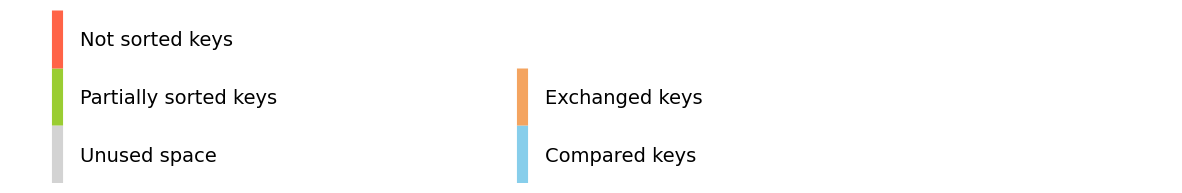

In [13]:
COLORS = [[COL_EMPTY,"Unused space"], [COL_PART_SORTED,"Partially sorted keys"], [COL_UNSORTED,"Not sorted keys"],
          [COL_COMPARISON,"Compared keys"], [COL_EXCHANGE,"Exchanged keys"]]
plt.figure(figsize=(15, 2.25))
plt.axis([0, 25, 0, 3])
plt.axis('off')
for i in range(3):
    plot_interval(1, [i+OFFSET,i+OFFSET], COLORS[i][0])
    plt.text(1+OFFSET, i+OFFSET, COLORS[i][1], verticalalignment='center_baseline', horizontalalignment='left', fontsize=FONTSIZE_LEGEND)
for i in range(2):
    plot_interval(11, [i+OFFSET,i+OFFSET], COLORS[i+3][0])
    plt.text(11+OFFSET, i+OFFSET, COLORS[i+3][1], verticalalignment='center_baseline', horizontalalignment='left', fontsize=FONTSIZE_LEGEND)
plt.show()

### Test data structure

insert 0
insert 1
insert 2
insert 3
insert 4
extract_max: 4
extract_max: 3
extract_max: 2
extract_max: 1
extract_max: 0
extract_max: False


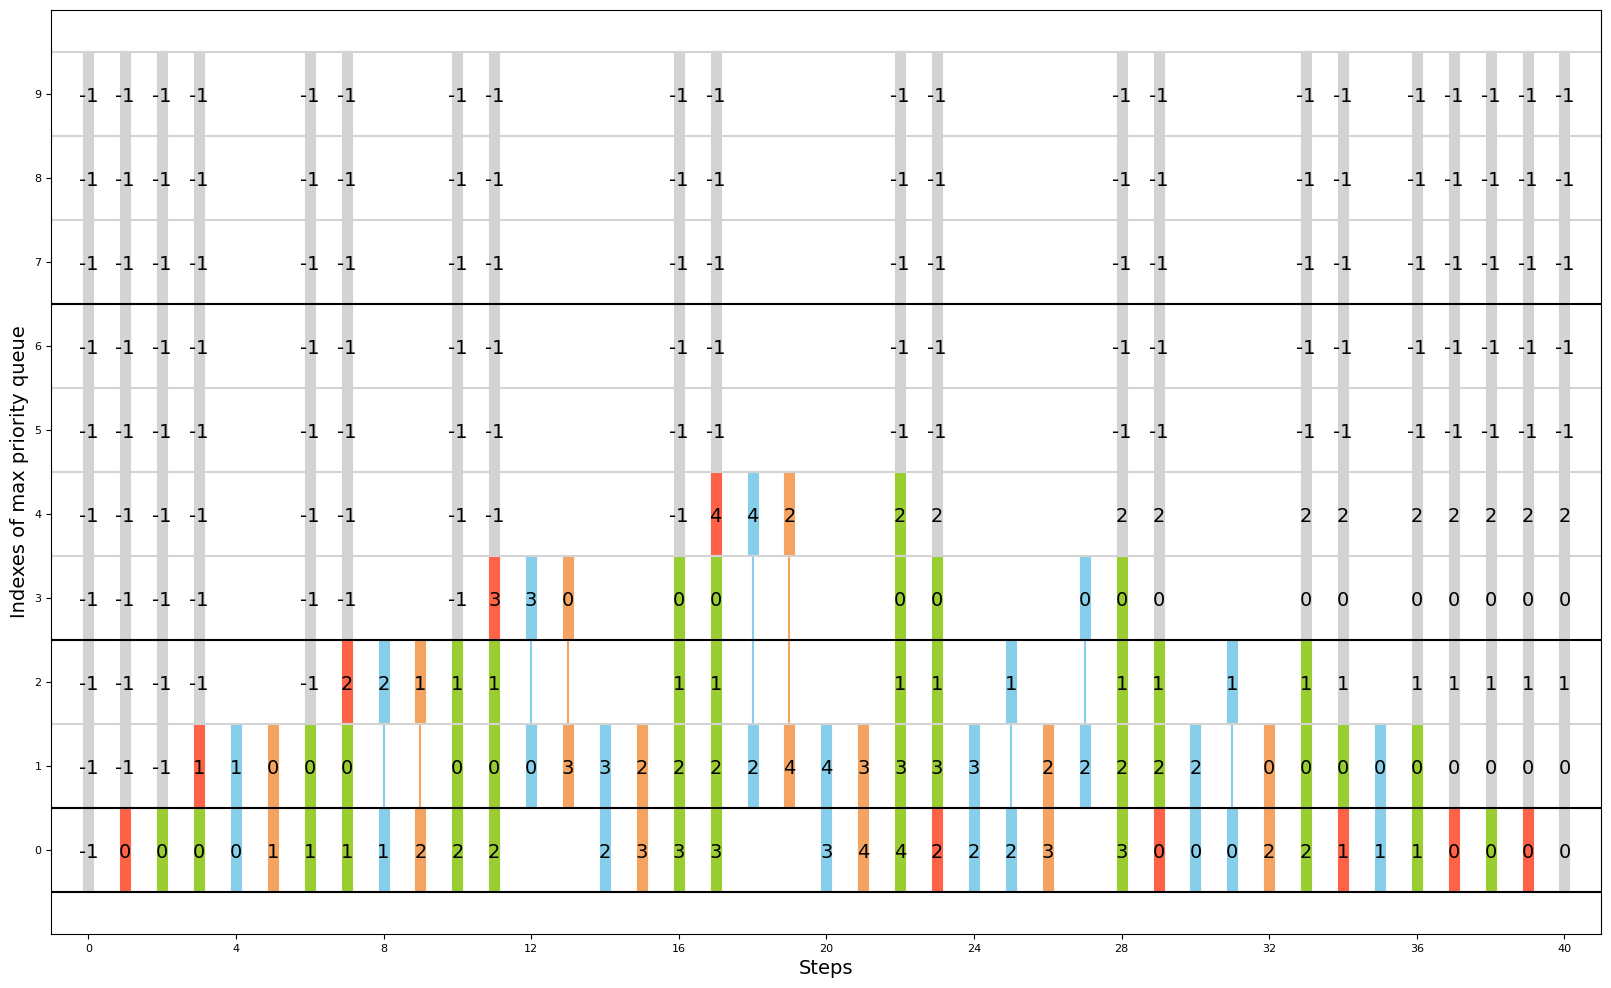

In [14]:
empty_max_priority_queue()
# test
num_elements=5
elements = [i for i in range(num_elements)]
for i in elements:
    print("insert", i)
    insert(i)
for i in elements:
    print("extract_max:", extract_max())
print("extract_max:", extract_max())
output_graphical_view(MAX_NUM_ELEMENTS)

Insert elements
[0]
[1, 0]
[2, 0, 1]
[3, 2, 1, 0]
[4, 3, 1, 0, 2]
Increase priority of all elements
True
[5, 4, 1, 3, 2]
True
[6, 4, 5, 3, 2]
True
[7, 6, 5, 3, 4]
True
[8, 7, 5, 6, 4]
True
[9, 8, 5, 6, 7]
Extract all elements and one more
9
[8, 7, 5, 6]
8
[7, 6, 5]
7
[6, 5]
6
[5]
5
[]
False


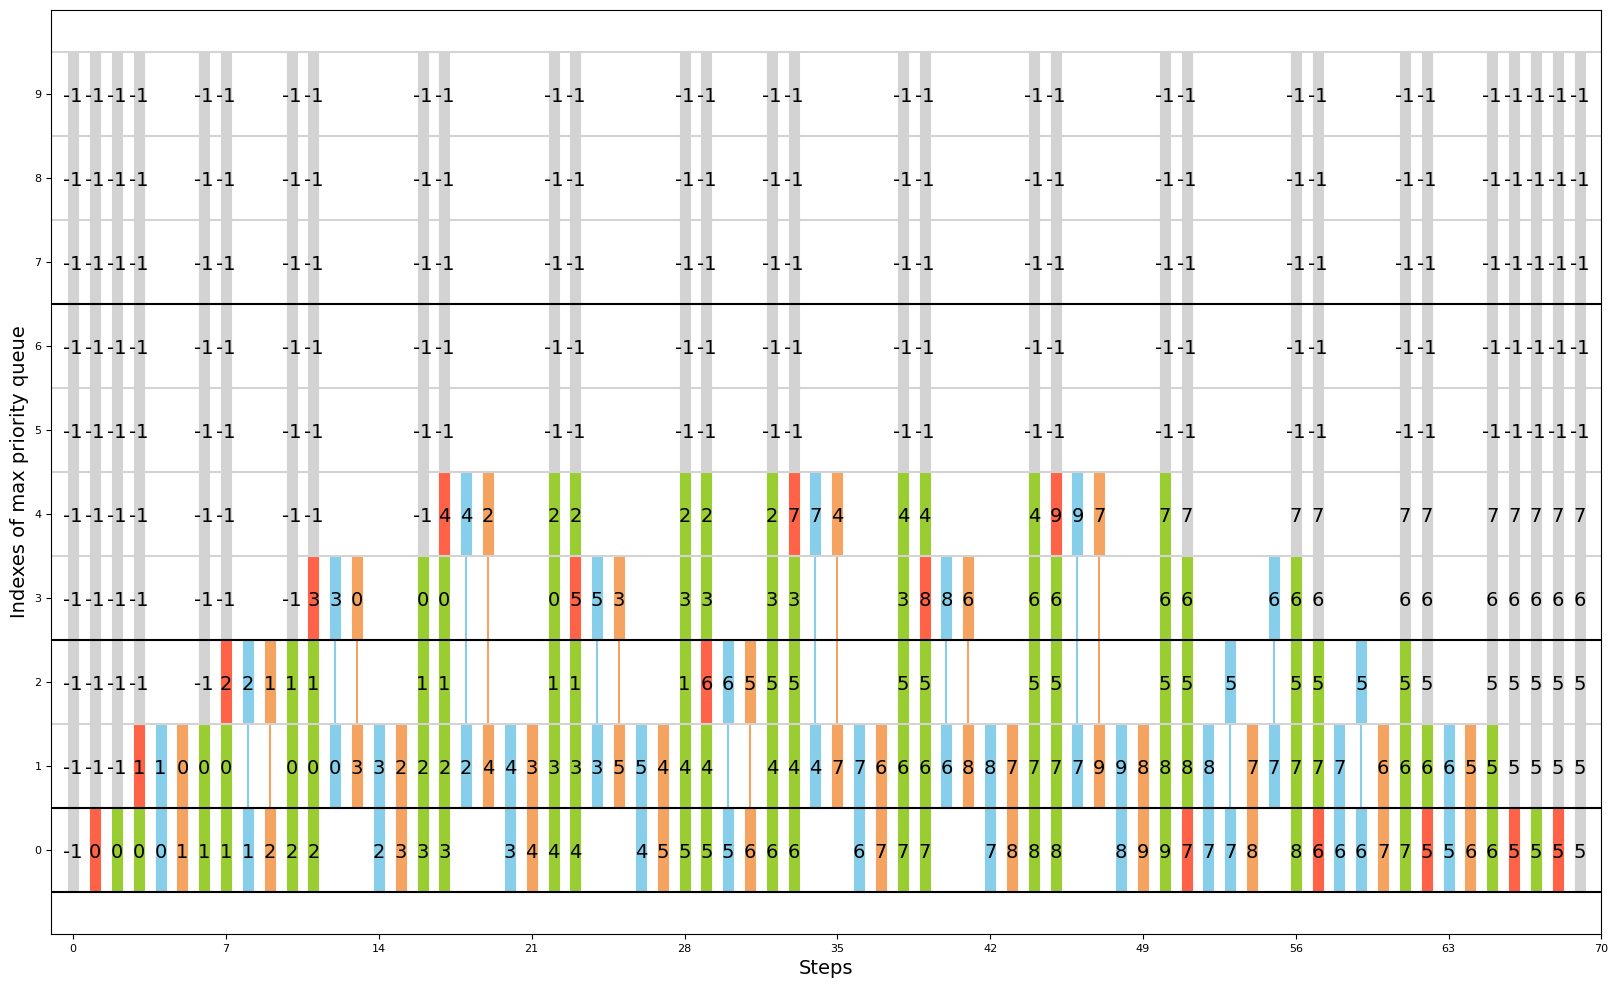

In [15]:
empty_max_priority_queue()
# test
num_elements=5
elements = [i for i in range(num_elements)]
print("Insert elements")
for i in elements:
    insert(i)
    print(heap[0:heapsize])
print("Increase priority of all elements")
for i in elements:
    index = heap.index(i)
    print(increase_priority(index, heap[index]+5))
    print(heap[0:heapsize])
print("Extract all elements and one more")
for i in elements:
    print(extract_max())
    print(heap[0:heapsize])
print(extract_max())
output_graphical_view(MAX_NUM_ELEMENTS)

## Your tests here ...

[4]
[7, 4]
[7, 4, 1]
[7, 4, 1, 2]
[7, 6, 1, 2, 4]
[7, 6, 3, 2, 4, 1]
[7, 6, 5, 2, 4, 1, 3]
[7, 6, 5, 2, 4, 1, 3, 0]
True
True
[9, 8, 5, 7, 4, 1, 3, 2]
9
[8, 7, 5, 2, 4, 1, 3]
8
[7, 4, 5, 2, 3, 1]
7
[5, 4, 1, 2, 3]


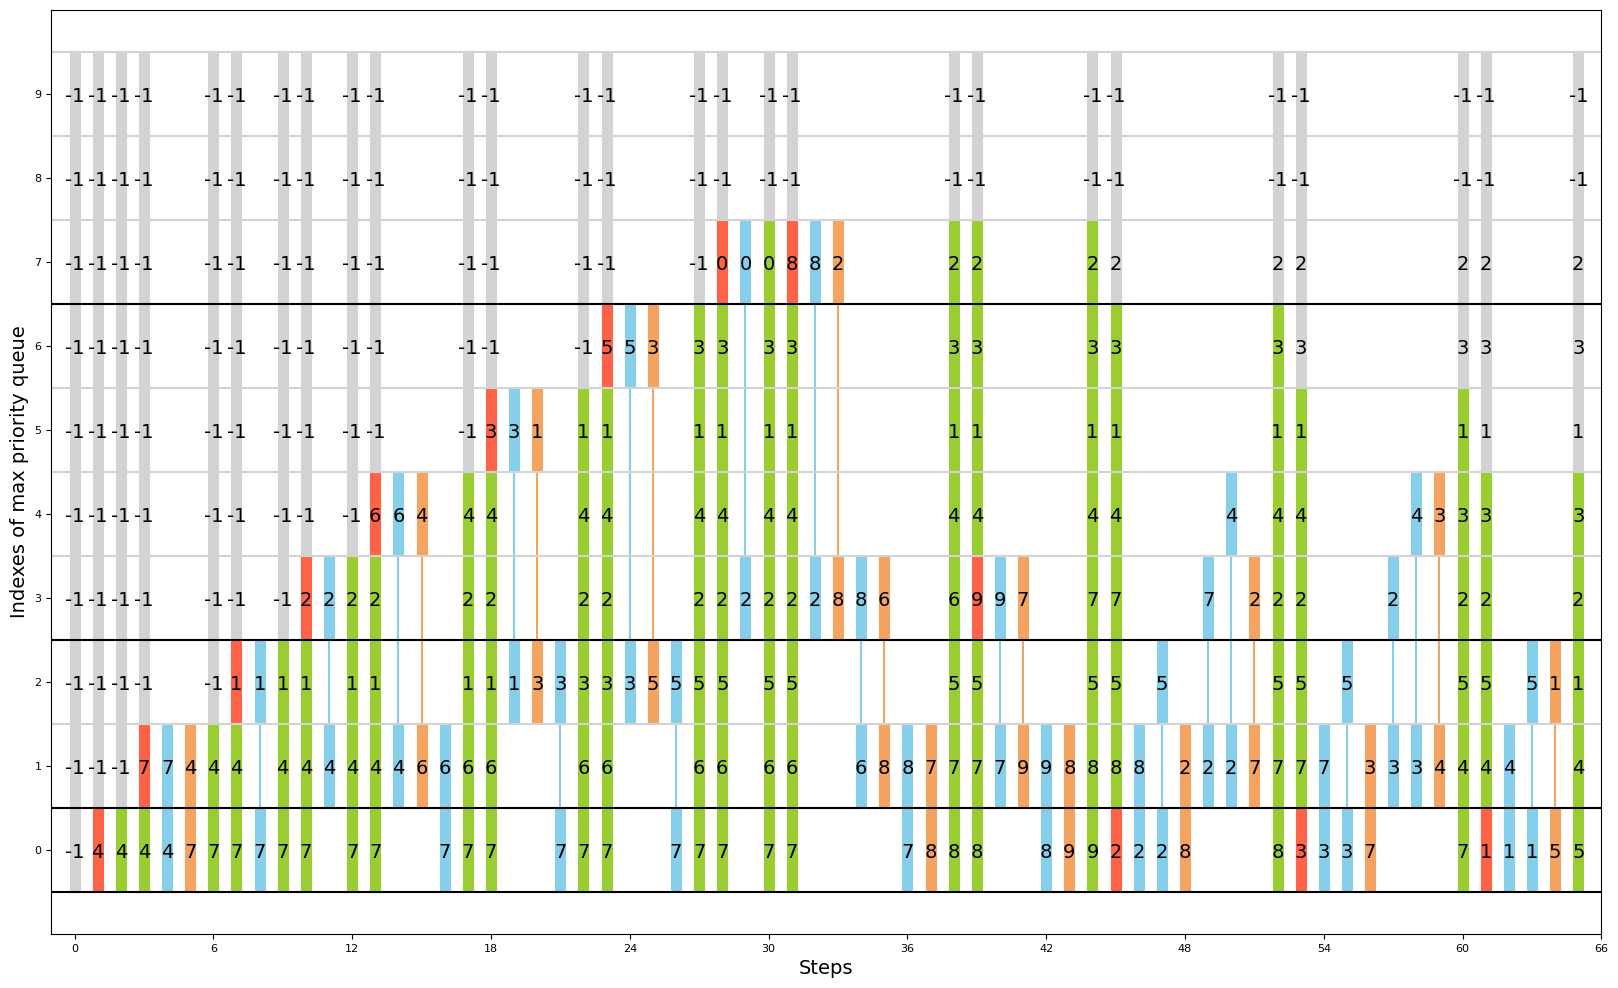

In [16]:
empty_max_priority_queue()
# test
elements = [4,7,1,2,6,3,5,0]
for i in elements:
    insert(i)
    print(heap[0:heapsize])
print(increase_priority(7,8))
print(increase_priority(3,9))
print(heap[0:heapsize])
for _ in range(3):
    print(extract_max())
    print(heap[0:heapsize])
output_graphical_view(MAX_NUM_ELEMENTS, "maxpriorityqueue")

In [17]:
# ... and here ...